# 09 - Boosted Models (untuned)

**Goal:** Train five boosted-tree regression families under the same fair protocol as 06–08. Tuning is strictly deferred to stage 11.

**Approved protocol:**
- Per fold, training set = `train_range ∩ fair_subset_indices` (~395k rows). Validation = full val slice (no subset).
- Fresh `RobustScaler` fit on each fold's training intersection (matches 06–08).
- All boosted models are single-output — each is wrapped in `MultiOutputRegressor` (fits one model per target).
- Roster (untuned, library defaults):
  - `gbr` – `GradientBoostingRegressor` (sklearn, classical sequential boosting).
  - `hgbr` – `HistGradientBoostingRegressor` (sklearn, histogram-based, fast).
  - `xgb` – `XGBRegressor` (xgboost).
  - `lgbm` – `LGBMRegressor` (lightgbm).
  - `catboost` – `CatBoostRegressor` (catboost).
- Metrics: MAE, RMSE, R² per target per fold; aggregated mean ± std across 5 folds.
- All 50 fitted (fold, model, target) artifacts saved to disk.

**Multi-output note:** Unlike 06–08 where most models were native multi-output, every model in this stage uses `MultiOutputRegressor`. This means each (fold, model) entry actually fits **two** independent sub-models (one per target). The deviation is explicitly documented.

**Runtime note:** Classical `GradientBoostingRegressor` is significantly slower than histogram-based variants on ~400k rows. Timing is logged per (fold, model).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import time
import warnings
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42

DATA_PATH    = Path('../data/processed/ethylene_methane.parquet')
SPLITS_PATH  = Path('../results/tables/validation_splits.parquet')
SUBSET_PATH  = Path('../data/subsets/fair_subset_indices.parquet')
MODEL_DIR    = Path('../results/models/boosted_09')
TABLES_DIR   = Path('../results/tables')
FIG_DIR      = Path('../results/figures')
MEMO_PATH    = Path('../results/memos/09_boosted_models.md')

for d in (MODEL_DIR, TABLES_DIR, FIG_DIR, MEMO_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']
TIME    = 'time_s'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## 1. Load Data, Splits, Fair Subset

In [2]:
df = pd.read_parquet(DATA_PATH, columns=[TIME] + SENSORS + TARGETS)
splits_df = pd.read_parquet(SPLITS_PATH)
subset_idx = pd.read_parquet(SUBSET_PATH)['row_idx'].to_numpy()

assert (np.diff(subset_idx) >= 0).all(), 'Subset indices not monotonic'

print(f'Dataset rows : {len(df):,}')
print(f'Subset rows  : {len(subset_idx):,}')
print(f'Folds        : {sorted(int(f) for f in splits_df["fold"].unique())}')

Dataset rows : 4,178,504
Subset rows  : 1,000,000
Folds        : [1, 2, 3, 4, 5]


## 2. Per-Fold Data Preparation

Same `prepare_fold(k)` as 06–08: training set = `train_range ∩ subset`, validation = full untouched fold-`k` val slice, fresh `RobustScaler` per fold.

In [3]:
def prepare_fold(fold_id):
    tr = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'train')].iloc[0]
    va = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'val')].iloc[0]

    train_idx = subset_idx[(subset_idx >= tr['start_idx']) & (subset_idx < tr['end_idx'])]
    val_idx   = np.arange(va['start_idx'], va['end_idx'])

    X_tr = df[SENSORS].iloc[train_idx].to_numpy()
    y_tr = df[TARGETS].iloc[train_idx].to_numpy()
    X_va = df[SENSORS].iloc[val_idx].to_numpy()
    y_va = df[TARGETS].iloc[val_idx].to_numpy()

    scaler = RobustScaler().fit(X_tr)
    return scaler.transform(X_tr), y_tr, scaler.transform(X_va), y_va, scaler

## 3. Boosted Model Roster

Five boosted-tree regressors, all at library defaults (untuned). Each is wrapped in `MultiOutputRegressor` since none natively supports multi-output regression.

In [4]:
def make_models():
    return {
        'gbr': MultiOutputRegressor(
            GradientBoostingRegressor(
                n_estimators=100, max_depth=3, learning_rate=0.1, random_state=SEED,
            )
        ),
        'hgbr': MultiOutputRegressor(
            HistGradientBoostingRegressor(
                max_iter=100, max_depth=None, learning_rate=0.1, random_state=SEED,
            )
        ),
        'xgb': MultiOutputRegressor(
            XGBRegressor(
                n_estimators=100, max_depth=6, learning_rate=0.3,
                random_state=SEED, verbosity=0,
            )
        ),
        'lgbm': MultiOutputRegressor(
            LGBMRegressor(
                n_estimators=100, max_depth=-1, learning_rate=0.1,
                random_state=SEED, verbosity=-1,
            )
        ),
        'catboost': MultiOutputRegressor(
            CatBoostRegressor(
                iterations=100, depth=6, learning_rate=0.1,
                random_seed=SEED, verbose=0,
            )
        ),
    }

print('Boosted roster (all wrapped in MultiOutputRegressor):')
for name, m in make_models().items():
    inner = m.estimator
    print(f'  {name:>10}: {inner.__class__.__name__}')

Boosted roster (all wrapped in MultiOutputRegressor):
         gbr: GradientBoostingRegressor
        hgbr: HistGradientBoostingRegressor
         xgb: XGBRegressor
        lgbm: LGBMRegressor
    catboost: CatBoostRegressor


## 4. Train & Evaluate per (fold, model)

Fit on the subset intersection, predict on the full val slice, record per-target metrics, persist the fitted model + its scaler. Timing logged per (fold, model) — GBR will be significantly slower.

In [5]:
records = []
timings = []
for fold_id in sorted(int(f) for f in splits_df['fold'].unique()):
    X_tr, y_tr, X_va, y_va, scaler = prepare_fold(fold_id)
    print(f'\nFold {fold_id}: train={X_tr.shape}, val={X_va.shape}')

    for name, model in make_models().items():
        t0 = time.perf_counter()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_va)
        elapsed = time.perf_counter() - t0
        timings.append({'fold': fold_id, 'model': name, 'seconds': round(elapsed, 1)})

        for t_idx, target in enumerate(TARGETS):
            records.append({
                'fold':   fold_id,
                'model':  name,
                'target': target,
                'mae':    float(mean_absolute_error(y_va[:, t_idx], y_pred[:, t_idx])),
                'rmse':   float(np.sqrt(mean_squared_error(y_va[:, t_idx], y_pred[:, t_idx]))),
                'r2':     float(r2_score(y_va[:, t_idx], y_pred[:, t_idx])),
            })

        out_path = MODEL_DIR / f'fold_{fold_id}_{name}.joblib'
        joblib.dump({'model': model, 'scaler': scaler, 'fold': fold_id, 'name': name}, out_path)
        print(f'  {name:>10}: {elapsed:7.1f}s')

metrics_long = pd.DataFrame(records)
print(f'\nTotal records: {len(metrics_long)}  (expect 5 folds × 5 models × 2 targets = 50)')
assert len(metrics_long) == 50

print('\nTiming summary (seconds per fold × model):')
timing_df = pd.DataFrame(timings)
print(timing_df.pivot(index='model', columns='fold', values='seconds').to_string())


Fold 1: train=(398670, 16), val=(407367, 16)
         gbr:   264.4s
        hgbr:     7.3s
         xgb:     2.8s


c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


        lgbm:     2.3s
    catboost:     6.8s

Fold 2: train=(391532, 16), val=(419449, 16)
         gbr:   257.0s
        hgbr:     4.8s
         xgb:     3.0s


c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


        lgbm:     2.5s
    catboost:     5.9s

Fold 3: train=(392782, 16), val=(407362, 16)
         gbr:   254.4s
        hgbr:     4.7s
         xgb:     2.2s


...

        lgbm:     1.8s
    catboost:     4.1s

Fold 4: train=(392275, 16), val=(431972, 16)
         gbr:   239.3s
        hgbr:     4.8s
         xgb:     3.0s


c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


        lgbm:     2.8s
    catboost:     6.2s

Fold 5: train=(399678, 16), val=(435098, 16)
         gbr:   249.9s
        hgbr:     4.3s
         xgb:     2.3s


c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\User\Desktop\gas_regression_fair_benchmark_v2\Comparative Analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


        lgbm:     2.0s
    catboost:     5.3s

Total records: 50  (expect 5 folds × 5 models × 2 targets = 50)

Timing summary (seconds per fold × model):
fold          1      2      3      4      5
model                                      
catboost    6.8    5.9    4.1    6.2    5.3
gbr       264.4  257.0  254.4  239.3  249.9
hgbr        7.3    4.8    4.7    4.8    4.3
lgbm        2.3    2.5    1.8    2.8    2.0
xgb         2.8    3.0    2.2    3.0    2.3


## 5. Aggregate & Save Metrics

In [6]:
long_path    = TABLES_DIR / '09_boosted_metrics_long.parquet'
summary_path = TABLES_DIR / '09_boosted_metrics_summary.parquet'

metrics_long.to_parquet(long_path, index=False)

summary = (metrics_long
           .groupby(['model', 'target'])[['mae', 'rmse', 'r2']]
           .agg(['mean', 'std'])
           .round(4))
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.reset_index()
summary.to_parquet(summary_path, index=False)

print('Per-fold metrics (head):')
print(metrics_long.head(12).to_string(index=False))
print()
print('Summary (mean ± std across folds):')
print(summary.to_string(index=False))
print()
print(f'Saved: {long_path}')
print(f'Saved: {summary_path}')

Per-fold metrics (head):
 fold    model       target       mae      rmse        r2
    1      gbr  methane_ppm 32.549630 61.473724  0.333871
    1      gbr ethylene_ppm  3.174263  5.094317  0.143315
    1     hgbr  methane_ppm 42.199349 84.091350 -0.246471
    1     hgbr ethylene_ppm  3.094943  4.861008  0.219987
    1      xgb  methane_ppm 51.208315 96.022562 -0.625272
    1      xgb ethylene_ppm  3.202880  5.016409  0.169317
    1     lgbm  methane_ppm 40.266299 79.558920 -0.115725
    1     lgbm ethylene_ppm  3.156059  5.023579  0.166941
    1 catboost  methane_ppm 39.472516 77.543454 -0.059912
    1 catboost ethylene_ppm  3.349089  4.997303  0.175633
    2      gbr  methane_ppm 26.471069 57.743577  0.550266
    2      gbr ethylene_ppm  2.799050  4.139958  0.477248

Summary (mean ± std across folds):
   model       target  mae_mean  mae_std  rmse_mean  rmse_std  r2_mean  r2_std
catboost ethylene_ppm    3.1750   0.8131     4.5076    1.0676   0.3237  0.1451
catboost  methane_ppm   27.

## 6. Figures

Three panels: (a) MAE by model and target with fold-std error bars, (b) methane predicted-vs-actual scatter for fold 1's best model, (c) same for ethylene. Best = highest mean R² across folds and targets.

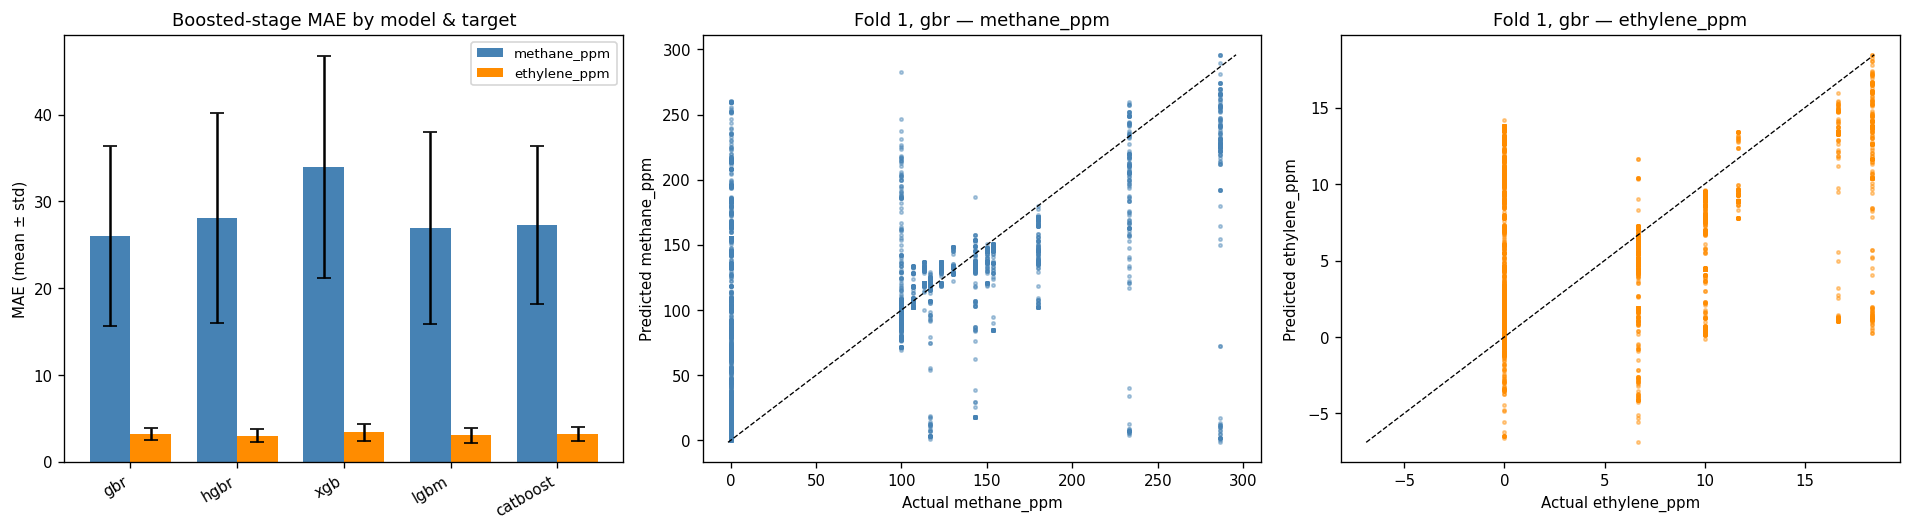

Saved: 09_boosted_models.png  (best boosted model by mean R²: gbr)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
models = list(make_models().keys())
colors = {'methane_ppm': 'steelblue', 'ethylene_ppm': 'darkorange'}

# (a) MAE bars
ax = axes[0]
x = np.arange(len(models))
w = 0.38
for offset, target in zip((-w/2, w/2), TARGETS):
    means = [metrics_long[(metrics_long['model']==m)&(metrics_long['target']==target)]['mae'].mean() for m in models]
    stds  = [metrics_long[(metrics_long['model']==m)&(metrics_long['target']==target)]['mae'].std()  for m in models]
    ax.bar(x + offset, means, w, yerr=stds, capsize=4, label=target, color=colors[target])
ax.set_xticks(x); ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_ylabel('MAE (mean ± std)'); ax.set_title('Boosted-stage MAE by model & target')
ax.legend(fontsize=8)

# Pick best model by mean R² (pooled across folds & targets, scale-free)
best = metrics_long.groupby('model')['r2'].mean().idxmax()
art  = joblib.load(MODEL_DIR / f'fold_1_{best}.joblib')
va   = splits_df[(splits_df['fold']==1)&(splits_df['split']=='val')].iloc[0]
X_va = df[SENSORS].iloc[va['start_idx']:va['end_idx']].to_numpy()
y_va = df[TARGETS].iloc[va['start_idx']:va['end_idx']].to_numpy()
y_pred = art['model'].predict(art['scaler'].transform(X_va))

n_plot = min(5000, len(y_va))
samp = np.random.default_rng(SEED).choice(len(y_va), n_plot, replace=False)

for ax, t_idx, target in zip(axes[1:], (0, 1), TARGETS):
    a = y_va[samp, t_idx]; p = y_pred[samp, t_idx]
    ax.scatter(a, p, s=4, alpha=0.4, color=colors[target])
    lo = float(min(a.min(), p.min())); hi = float(max(a.max(), p.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
    ax.set_xlabel(f'Actual {target}'); ax.set_ylabel(f'Predicted {target}')
    ax.set_title(f'Fold 1, {best} — {target}')

plt.tight_layout()
plt.savefig(FIG_DIR / '09_boosted_models.png', bbox_inches='tight')
plt.show()
print(f'Saved: 09_boosted_models.png  (best boosted model by mean R²: {best})')

## 7. Save Memo

In [8]:
def df_to_md(t):
    header = '| ' + ' | '.join(str(c) for c in t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |' for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

ranking = (metrics_long.groupby('model')[['mae', 'rmse', 'r2']]
           .mean().round(4).reset_index()
           .sort_values('r2', ascending=False))
best_model = ranking.iloc[0]['model']

lines = [
    '# 09 - Boosted Models (untuned)',
    '',
    '**Date:** 2026-05-23',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Splits artifact:** {SPLITS_PATH.as_posix()}',
    f'**Subset artifact:** {SUBSET_PATH.as_posix()}',
    '',
    '---',
    '',
    '## Protocol',
    '- Per fold: training set = `train_range ∩ fair_subset` (~395k rows). Validation = full val slice (untouched).',
    '- Fresh `RobustScaler` fit on each fold\'s training intersection; applied to train and val.',
    '- All models wrapped in `MultiOutputRegressor` (one fit per target). This is the documented deviation from 06–08.',
    '- 5 folds × 5 models × 2 targets = 50 metric records.',
    '',
    '## Roster',
    '- `gbr`      – `GradientBoostingRegressor(n_estimators=100, max_depth=3, lr=0.1)`, sklearn classical.',
    '- `hgbr`     – `HistGradientBoostingRegressor(max_iter=100, lr=0.1)`, sklearn histogram.',
    '- `xgb`      – `XGBRegressor(n_estimators=100, max_depth=6, lr=0.3)`, xgboost.',
    '- `lgbm`     – `LGBMRegressor(n_estimators=100, lr=0.1)`, lightgbm.',
    '- `catboost` – `CatBoostRegressor(iterations=100, depth=6, lr=0.1)`, catboost.',
    '',
    '## Ranking (mean across folds & targets, sorted by R² descending)',
    '',
    'Note: MAE/RMSE pool across two targets with different scales; R² is the scale-free comparator.',
    '',
    df_to_md(ranking),
    '',
    f'**Best boosted model:** `{best_model}`',
    '',
    '## Summary (mean ± std across 5 folds, per target)',
    '',
    df_to_md(summary),
    '',
    '## Artifacts',
    f'- Per-fold metrics: `{long_path.as_posix()}`',
    f'- Summary metrics:  `{summary_path.as_posix()}`',
    f'- Fitted models:    `{MODEL_DIR.as_posix()}/fold_{{k}}_{{name}}.joblib` (25 files)',
    f'- Figure:           `{(FIG_DIR / "09_boosted_models.png").as_posix()}`',
    '',
    '## Next step',
    'Notebook `10_neural_models.ipynb` (pending approval): MLP and TabNet under the same protocol.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\09_boosted_models.md
